# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**: Bor-Jiun Tseng

**ID**: bt366

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [37]:
Pkg.add("Turing")
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

   Resolving package versions...
   Installed StatisticalTraits ────────── v3.4.0
   Installed LRUCache ─────────────────── v1.6.1
   Installed ConsoleProgressMonitor ───── v0.1.2
   Installed Accessors ────────────────── v0.1.42
   Installed AbstractMCMC ─────────────── v5.6.0
   Installed AxisArrays ───────────────── v0.4.7
   Installed AdvancedPS ───────────────── v0.6.1
   Installed NNlib ────────────────────── v0.9.28
   Installed NaturalSort ──────────────── v1.0.0
   Installed EnumX ────────────────────── v1.0.4
   Installed ProgressMeter ────────────── v1.10.2
   Installed InitialValues ────────────── v0.3.1
   Installed Optimisers ───────────────── v0.4.5
   Installed Roots ────────────────────── v2.2.6
   Installed RecursiveArrayTools ──────── v3.31.0
   Installed FunctionWrappers ─────────── v1.1.3
   Installed Turing ───────────────────── v0.36.3
   Installed ZygoteRules ──────────────── v0.2.7
   Installed LogDensityProblemsAD ─────── v1.13.0
   Installed RealDot ─────────

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [38]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using Turing

## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, \$(3, 40), which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

Question 1: From HW1, each students follow the steps:
1. Flip a fair coin, if heads → Answer honestly.
2. If tails → Flip again
3. If heads → Say "Yes, I cheated" regardless of the truth.
4. If tails → Say "No, I didn’t cheat" regardless of the truth
- $\theta$ = true proportion of students who cheated
- The probability of a student responding "Yes, I cheated" is: $$P(Y = 1 \mid \theta) = \frac{1}{2} \theta + \frac{1}{4} (1 - \theta)$$
- We surveyed 100 students, and got 40 yes response, so we can model this as a binomial likelihood function.
- $$P(Y = 40 \mid \theta) = \binom{100}{40} \left( \frac{1+\theta}{4} \right)^{40} \left( 1 - \frac{1+\theta}{4} \right)^{60}$$
5. I first assume a Beta Prior of $\theta$: $$\theta \sim \text{Beta}(3, 40)$$
6. Beta-Binomial Conjugacy $$\theta | Y \sim \text{Beta}(\alpha + Y, \beta + (n - Y))$$
- therefore I update the equation $$\theta | Y = 40 \sim \text{Beta}(3 + 40, 40 + (100 - 40))$$ $$\theta | Y \sim \text{Beta}(43, 100)$$
7. The mean of Beta distribution is 43/143 = 0.3
8. 95% Credible Interval = [0.229,0.378]

In [10]:
alpha_post = 43
beta_post = 100
posterior = Beta(alpha_post, beta_post)

# 95% credible interval
cred_interval = quantile(posterior, [0.025, 0.975])

2-element Vector{Float64}:
 0.22858838990978478
 0.37809033222817967

Question 2

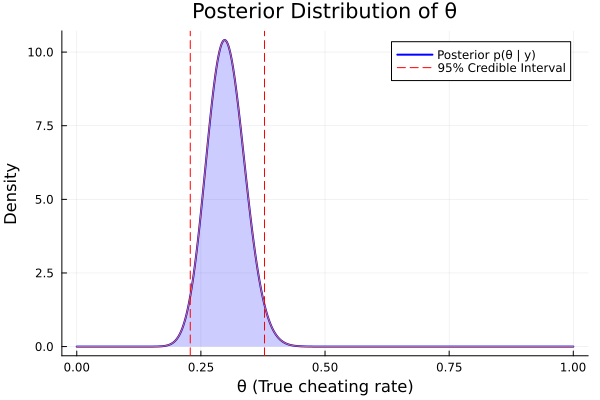

In [ ]:
#1000 samples loop
theta_vals = range(0, 1, length=1000)
posterior_pdf = pdf.(posterior, theta_vals)
p1 = plot(theta_vals, posterior_pdf, label="Posterior p(θ | y)", linewidth=2, color=:blue, xlabel="θ (True cheating rate)", ylabel="Density", title="Posterior Distribution of θ", legend=:topright)
plot!(theta_vals, posterior_pdf, fill=(0, :blue, 0.2), label="")
vline!(cred_interval, linestyle=:dash, color=:red, label="95% Credible Interval")
display(p1)


Question 3
1. Define Two Distributions
2. Find the Maximum of the Posterior
3. Generate random Samples

- Answer: I think the histogram (distribution of sample values using rejection sampling) closely follows the true posterior shape, meaning rejection sampling capturing the posterior pretty ok.
- Answer2: Yes, with more samples, the histogram would better approximate the true posterior, but it is more important when making precise credible interval estimates.

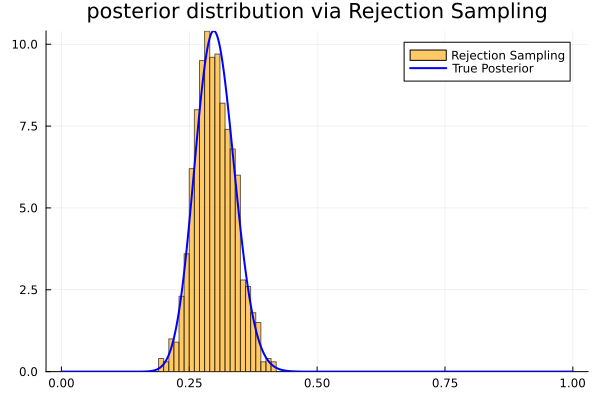

In [35]:
# samples numbers
num_samples = 1000  
samples = Float64[]
#proposal distribution
proposal_dist = Uniform(0, 1)

#maximum value of the posterior as scaling
theta_vals = range(0, 1, length=1000)
max_posterior = maximum(pdf.(posterior, theta_vals))  # Maximum density

# Rejection sampling loop
while length(samples) < num_samples
    theta_candidate = rand(proposal_dist) 
    u = rand() * max_posterior
    
    if u <= pdf(posterior, theta_candidate)
        push!(samples, theta_candidate)
    end
end

histogram(samples, bins=30, normalize=true, alpha=0.6, label="Rejection Sampling", color=:orange)

p2 = plot!(theta_vals, pdf.(posterior, theta_vals), linewidth=2, color=:blue, label="True Posterior", title = "posterior distribution via Rejection Sampling")
display(p2)

Question 4
- After computing, we get Expected value of $\theta$ = 0.30 (30%)
- 90% Credible Interval:[0.24,0.37]
1. The cheating rate is higher than expected, the posterior estimate suggests a cheating rate of approximately 30%, but my initial belief was that cheating was 5% or less, and The 90% credible interval of [24%,37%] means we are pretty confident that at least 24% of students cheated.
2. There is Still Some Uncertainty, 90% credible interval from (24% to 37%), so that we still have some uncertainty about the exact cheating rate.

In [25]:
expected_theta = mean(posterior)
credible_interval_90 = quantile(posterior, [0.05, 0.95])
# Compute 90% credible interval
@show expected_theta
@show credible_interval_90


expected_theta = 0.3006993006993007
credible_interval_90 = [0.23944251158739155, 0.3651364331785457]


2-element Vector{Float64}:
 0.23944251158739155
 0.3651364331785457

After using the Beta(5,20) prior, our updated posterior analysis gives:
- Expected value of θ: 0.36 (36%)
- 90% Credible Interval: [29.1%,43.2%]
1. The estimated cheating rate increased from 30% to 36%, so it might be even more common than we initially thought.
2. The credible interval is slightly wider because of greater flexibility, so the uncertainty range expands slightly.
3. The randomized response technique still introduces uncertainty, since student's response will always be partially random.

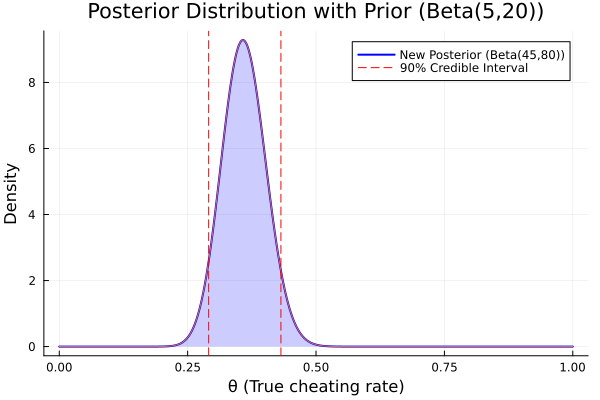

new_expected_theta = 0.36
new_credible_interval_90 = [0.29092540393516303, 0.4316320815948793]


In [ ]:
#less constrained prior
alpha_prior2 = 5
beta_prior2 = 20
num_yes = 40
num_total = 100
alpha_post2 = alpha_prior2 + num_yes
beta_post2 = beta_prior2 + (num_total - num_yes)
posterior2 = Beta(alpha_post2, beta_post2)
new_expected_theta = mean(posterior2);
new_credible_interval_90 = quantile(posterior2, [0.05, 0.95]);
@show new_expected_theta
@show new_credible_interval_90
# Plot posterior distribution
theta_vals = range(0, 1, length=1000)
new_posterior_pdf = pdf.(posterior2, theta_vals)

p3 = plot(theta_vals, new_posterior_pdf, label="New Posterior (Beta(45,80))", linewidth=2, color=:blue, xlabel="θ (True cheating rate)", ylabel="Density", title="Posterior Distribution with Prior (Beta(5,20))", legend=:topright)
fill_between = plot!(theta_vals, new_posterior_pdf, fill=(0, :blue, 0.2), label="")
vline!(new_credible_interval_90, linestyle=:dash, color=:red, label="90% Credible Interval")

display(p3)

**In this problem**:

-   Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?

### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

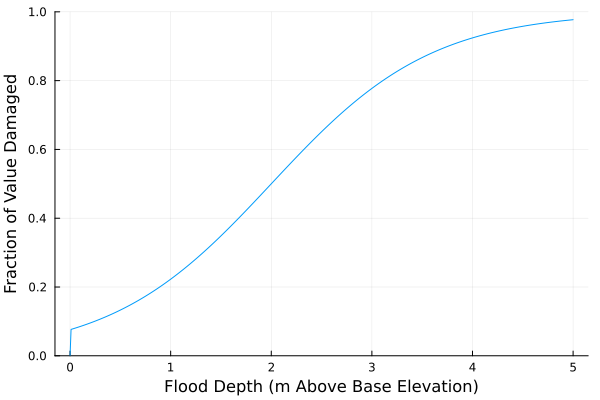

In [ ]:
 h = 0:0.01:5
 dd(h, k, x₀) = (h .> 0) * 1 ./ (1 .+ exp.(-k * (h .- x₀)))
 plot(h, dd(h, 1.25, 2), xlabel="Flood Depth (m Above Base Elevation)", ylabel="Fraction of Value Damaged", legend=false)
 ylims!(0, 1)

For Problem 2 Question 1
- I first defined a log likelyhood function
- then takes the log of each water depth standard deviation and finds the average for the starting guess for both $\mu$ and $\sigma$.
- Then I set lower bound on sigma for non negative.
- Then I use optimization, getting a log-mean of 0.141 and a log-standard deviation of 0.25.

In [153]:
df = CSV.read("data/water_depths.csv", DataFrame)
water_depths = df.depths;

In [161]:
#Fit Log-Normal Distribution
log_water_depths = log.(water_depths)  #log-scale
mu_mle = mean(log_water_depths)  #log-mean
sigma_mle = std(log_water_depths, corrected=true)  #log-standard deviation

println("Fitted Log-Normal Distribution: μ = ", round(mu_mle, digits=3), ", σ = ", round(sigma_mle, digits=3))


Fitted Log-Normal Distribution: μ = 0.141, σ = 0.253


In [171]:
#Define Depth-Damage Function
function depth_damage(h, k, x0)
    if h <= 1.5
        return 0.0  # damage below 1.5m
    else
        return 1 / (1 + exp(-1.25 * (h - 2))) # function
    end
end

depth_damage (generic function with 4 methods)

In [ ]:
# Parameters
home_value = 400000
k, x0 = 1.25, 2  # Damage function
num_samples = 10_000
Random.seed!(26) 
flood_depth_samples = rand(LogNormal(mu_mle, sigma_mle), num_samples)
damages = [depth_damage(h) * home_value for h in flood_depth_samples]

# expected damage and standard error
expected_damage_mc = mean(damages)
std_error = std(damages, corrected=true) / sqrt(num_samples)  # Standard error of the mean

println("Expected Annual Flood Damage: \$", round(expected_damage_mc, digits=2))
println("Standard Error: \$", round(std_error, digits=2))

Expected Annual Flood Damage: $24295.67
Standard Error: $593.05


- Using monte carlo with 10000 sample sizes, and computing Damages for Each Flood Event, I was able to get
- Expected Annual Damage of $24296, so on average the homeowner will lose about $24296 per year because of flood.
- Standard Error of $593, which is pretty small compare to the total damage
3. Since the standard error is pretty small compare to the average damage, I probably will stop here on sample sizes.

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?

### Problem 3

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

Next, your client would like advice on whether it would be
cost-effective to elevate their home to reduce flood risks. To address
this question, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

> **Tip**
>
> Be careful about the quantity you’re estimating. Calculating the
> benefits of elevating by $\Delta h$ m requires calculating how the
> elevation *changes* the expected flooding damages over the design
> horizon *relative to a no-heightening baseline*.

**In this problem**:

-   Using the extreme water level distribution from Problem 2, use Monte
    Carlo simulation to estimate the NPV of the benefits of elevation
    levels between 0 and 5m (you don’t have to consider increments finer
    than 0.5m). What elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - ocsts)?[1]

[1] This is an example of **Monte Carlo optimization** as you are using
Monte Carlo simulation to estimate the optimization objective function.

For this porblem
1. Net Benefits = NPV of Avoided Flood Damages − Elevation Cost, I'll considered 0-5meters, in a 0.5 increment.
2. This tells us the total present-day value of flood damages over 30 years if the house is not elevated.
3. When a house is elevated, floodwaters affect it differently. If a flood depth is 2.5m, but the house is elevated 1m, the effective flood depth is now 1.5m.
4. For each elevation height(0-5m) in 0.5 increment, I calculate
- New expected annual flood damage using the adjusted flood depths.
- New NPV of flood damages over 30 years with elevation.
- How much flood damage is avoided by subtracting this from the baseline
5. From my calculation, all elevation starting from 0.5m pass the cost-benefit test, the fraction damage done to the building annually is very large to make the cost worth it, I tried to recalculate the damage equation, 1.6m of flood can already do 37% of damage.
6. repeat for each elevation height to get the best elevation height which in this case is 1.5m

In [189]:
function compute_npv_avoided_damages()
    # Compute NPV of flood damages over 30 year
    npv_damage_baseline = sum([expected_damage_mc * (1 - γ)^t for t in 0:T])

    elevation_net_benefits = []

    # Compute NPV for each elevation height
    for Δh in elevation_heights
        adjusted_flood_samples = flood_depth_samples .- Δh

        # new damages using the depth-damage function
        adjusted_damages = [
            (h_adj > 1.5 ? (1 / (1 + exp(-k * (h_adj - x0))) * home_value) : 0)
            for h_adj in adjusted_flood_samples
        ]

        # expected annual damage after elevation
        expected_damage_elevated = mean(adjusted_damages)

        # NPV of reduced damages
        npv_damage_elevated = sum([expected_damage_elevated * (1 - γ)^t for t in 0:T])

        # avoided damages
        npv_avoided = npv_damage_baseline - npv_damage_elevated

        # elevation cost
        elevation_cost = (Δh > 0) * (elevation_cost_base + elevation_cost_per_m * Δh)

        # net benefit
        net_benefit = npv_avoided - elevation_cost

        push!(elevation_net_benefits, (Δh, npv_avoided, elevation_cost, net_benefit))
    end

    #maximizes net benefit
    optimal_elevation = argmax(last, elevation_net_benefits)
    println("Elevation (m) | NPV Avoided (\$) | Elevation Cost (\$) | Net Benefit (\$)")
    for (h, npv_avoided, cost, nb) in elevation_net_benefits
        println(lpad(h, 10), " m  | ", 
                lpad(round(npv_avoided, digits=2), 10),
                lpad(round(cost, digits=2), 10),
                lpad(round(nb, digits=2), 10))
    end

    println("Maximum Net Benefit: ", optimal_elevation[1], "m")
end

compute_npv_avoided_damages()



Elevation (m) | NPV Avoided ($) | Elevation Cost ($) | Net Benefit ($)
       0.0 m  |        0.0       0.0       0.0
       0.5 m  |  396917.77  101000.0 295917.77
       1.0 m  |  434379.65  102000.0 332379.65
       1.5 m  |  436044.51  103000.0 333044.51
       2.0 m  |  436044.51  104000.0 332044.51
       2.5 m  |  436044.51  105000.0 331044.51
       3.0 m  |  436044.51  106000.0 330044.51
       3.5 m  |  436044.51  107000.0 329044.51
       4.0 m  |  436044.51  108000.0 328044.51
       4.5 m  |  436044.51  109000.0 327044.51
       5.0 m  |  436044.51  110000.0 326044.51
Maximum Net Benefit: 1.5m


In [ ]:
function npv_avoided_damages_mc()
    # 0m to 5m in 0.5m increments
    elevation_heights = 0:0.5:5
    num_samples = 10_000

    # flood depth samples
    flood_depth_samples = rand(LogNormal(mu_mle, sigma_mle), num_samples)

    # NPV of flood damages over 30 years Baseline
    npv_damage_baseline = sum([expected_damage_mc * (1 - γ)^t for t in 0:T])

    elevation_results = []

    for Δh in elevation_heights
        #samples for elevation
        adjusted_flood_samples = max.(0, flood_depth_samples .- Δh)

        # new damages using the depth-damage function
        adjusted_damages = [
            h_adj > 1.5 ? (1 / (1 + exp(-k * (h_adj - x0))) * home_value) : 0
            for h_adj in adjusted_flood_samples
        ]

        # new expected annual damage after elevation
        expected_damage_elevated = mean(adjusted_damages)

        # NPV of reduced damages over 30 years
        npv_damage_elevated = sum([expected_damage_elevated * (1 - γ)^t for t in 0:T])

        # avoided damages (how much flood damages are reduced)
        npv_avoided = npv_damage_baseline - npv_damage_elevated

        # elevation cost
        elevation_cost = (Δh > 0) * (elevation_cost_base + elevation_cost_per_m * Δh)

        # net benefit
        net_benefit = npv_avoided - elevation_cost

        push!(elevation_results, (Δh, npv_avoided, elevation_cost, net_benefit))
    end

    println("Elevation (m) | NPV Avoided (\$) | Elevation Cost (\$) | Net Benefit (\$)")
    println("--------------------------------------------------------------------")
    for (h, npv_avoided, cost, nb) in elevation_results
        @printf("%10.2f m  | %12.2f \$ | %12.2f \$ | %12.2f \$\n", h, npv_avoided, cost, nb)
    end

    # Find optimal elevation height
    optimal_elevation = argmax(last, elevation_results)
    println("\nOptimal Elevation Height for Maximum Net Benefit: ", optimal_elevation[1], "m")
end

npv_avoided_damages_mc()


Elevation (m) | NPV Avoided ($) | Elevation Cost ($) | Net Benefit ($)
--------------------------------------------------------------------
      0.00 m  |     10356.11 $ |         0.00 $ |     10356.11 $
      0.50 m  |    395317.07 $ |    101000.00 $ |    294317.07 $
      1.00 m  |    433996.78 $ |    102000.00 $ |    331996.78 $
      1.50 m  |    435777.49 $ |    103000.00 $ |    332777.49 $
      2.00 m  |    436044.51 $ |    104000.00 $ |    332044.51 $
      2.50 m  |    436044.51 $ |    105000.00 $ |    331044.51 $
      3.00 m  |    436044.51 $ |    106000.00 $ |    330044.51 $
      3.50 m  |    436044.51 $ |    107000.00 $ |    329044.51 $
      4.00 m  |    436044.51 $ |    108000.00 $ |    328044.51 $
      4.50 m  |    436044.51 $ |    109000.00 $ |    327044.51 $
      5.00 m  |    436044.51 $ |    110000.00 $ |    326044.51 $

Optimal Elevation Height for Maximum Net Benefit: 1.5m
